## "Green-SLA" Optimization Engine

#### In cloud computing, a Service Level Agreement (SLA) is a contract between a provider (like Google Cloud) and a user. It guarantees that the provider will run tasks within a certain timeframe. If the task is delayed, the provider breaks the SLA and loses money.

#### The Problem: The electrical grid’s carbon footprint changes every hour. When the sun is shining or the wind is blowing, the energy is clean (low carbon intensity). When everyone turns on their ACs at night, power plants burn coal or gas (high carbon intensity).

#### The "Green-SLA" Solution: It is an intelligent scheduling system. It looks at a queue of massive computational tasks (like training an ML model or processing data), predicts when the electrical grid will be the "cleanest," and schedules the tasks to run during those green windows without breaking the SLA deadline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset

In [3]:
df = pd.read_csv('E:\green_sla_project\PJME_hourly.csv')

<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:3: SyntaxWarning: invalid escape sequence '\g'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22716\3327951253.py:3: SyntaxWarning: invalid escape sequence '\g'
  df = pd.read_csv('E:\green_sla_project\PJME_hourly.csv')


### Inspect the structure

In [5]:
print("--- Dataset Info ---")
print(df.info())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB
None


In [7]:
print("\n--- First 5 Rows ---")
print(df.head())


--- First 5 Rows ---
              Datetime  PJME_MW
0  2002-12-31 01:00:00  26498.0
1  2002-12-31 02:00:00  25147.0
2  2002-12-31 03:00:00  24574.0
3  2002-12-31 04:00:00  24393.0
4  2002-12-31 05:00:00  24860.0


In [9]:
# Convert Datetime column from string to a proper datetime object
df['Datetime'] = pd.to_datetime(df['Datetime'])

In [11]:
# Set the Datetime column as the index of our dataframe
df.set_index('Datetime', inplace=True)

In [13]:
# Sort the index chronologically (vital for time-series splits)
df.sort_index(inplace=True)

In [15]:
# Rename the column to 'carbon_proxy' to match our project theme
df.rename(columns={'PJME_MW': 'carbon_proxy'}, inplace=True)

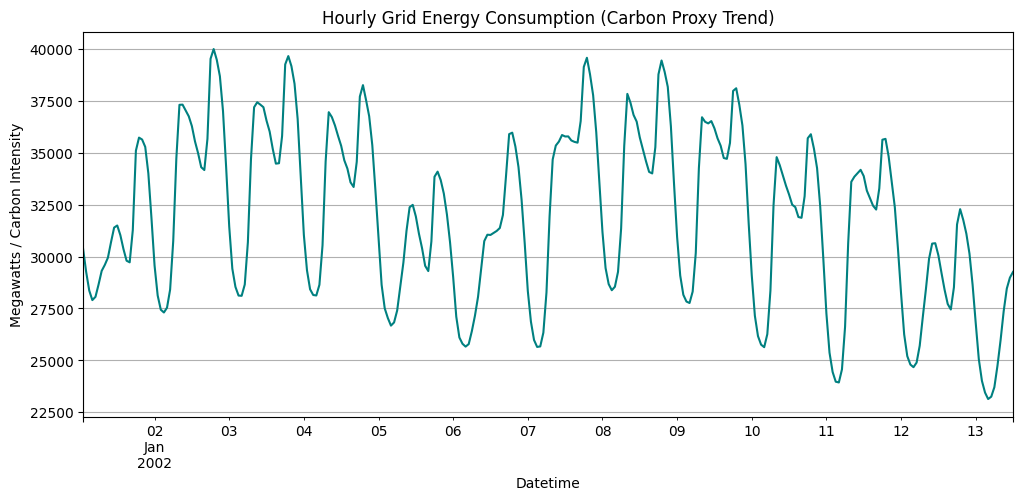

In [17]:
# Visualize the first 300 hours to see the daily cyclical pattern
df['carbon_proxy'].head(300).plot(figsize=(12, 5), color='teal')
plt.title('Hourly Grid Energy Consumption (Carbon Proxy Trend)')
plt.ylabel('Megawatts / Carbon Intensity')
plt.grid(True)
plt.show()

In [19]:
def create_time_features(data):
    df_feat = data.copy()
    
    # Extract structural time components
    df_feat['hour'] = df_feat.index.hour
    df_feat['day_of_week'] = df_feat.index.dayofweek
    df_feat['month'] = df_feat.index.month
    df_feat['quarter'] = df_feat.index.quarter
    
    # Create target lags (What was the value exactly 1 day ago and 1 week ago?)
    df_feat['lag_24h'] = df_feat['carbon_proxy'].shift(24)
    df_feat['lag_168h'] = df_feat['carbon_proxy'].shift(168)
    
    # Create rolling averages to capture recent trends
    df_feat['rolling_mean_6h'] = df_feat['carbon_proxy'].shift(1).rolling(window=6).mean()
    
    # Drop rows containing NaN values generated by lagging
    df_feat.dropna(inplace=True)
    
    return df_feat

# Run the feature engineering pipeline
processed_df = create_time_features(df)
print("\n--- Feature Engineered Dataset ---")
print(processed_df.head())


--- Feature Engineered Dataset ---
                     carbon_proxy  hour  day_of_week  month  quarter  lag_24h  \
Datetime                                                                        
2002-01-08 01:00:00       29445.0     1            1      1        1  26862.0   
2002-01-08 02:00:00       28670.0     2            1      1        1  25976.0   
2002-01-08 03:00:00       28375.0     3            1      1        1  25641.0   
2002-01-08 04:00:00       28542.0     4            1      1        1  25666.0   
2002-01-08 05:00:00       29261.0     5            1      1        1  26328.0   

                     lag_168h  rolling_mean_6h  
Datetime                                        
2002-01-08 01:00:00   30393.0     36150.166667  
2002-01-08 02:00:00   29265.0     34460.833333  
2002-01-08 03:00:00   28357.0     32775.833333  
2002-01-08 04:00:00   27899.0     31208.833333  
2002-01-08 05:00:00   28057.0     29966.333333  


In [27]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [25]:
from sklearn.metrics import r2_score

In [29]:
# 1. Separate Features (X) and Target (y)
X = processed_df.drop(columns=['carbon_proxy'])
y = processed_df['carbon_proxy']

In [31]:
# 2. Chronological Train-Test Split (80% Train, 20% Test)
split_idx = int(len(processed_df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

Training samples: 116158 | Testing samples: 29040


In [33]:
# 3. Initialize and Train the Regressor
# Using conservative estimators for a fast, stable baseline train
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
print("Training Gradient Boosting model... (this might take a few moments)")
model.fit(X_train, y_train)
print("Training complete!")

Training Gradient Boosting model... (this might take a few moments)
Training complete!


In [35]:
# 4. Predict on Test Data
predictions = model.predict(X_test)

In [37]:
# 5. Calculate Metrics
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("\n--- Model Baseline Performance Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} MW")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} MW")
print(f"R² Variance Score: {r2:.4f}")


--- Model Baseline Performance Evaluation ---
Mean Absolute Error (MAE): 1040.35 MW
Root Mean Squared Error (RMSE): 1381.97 MW
R² Variance Score: 0.9547


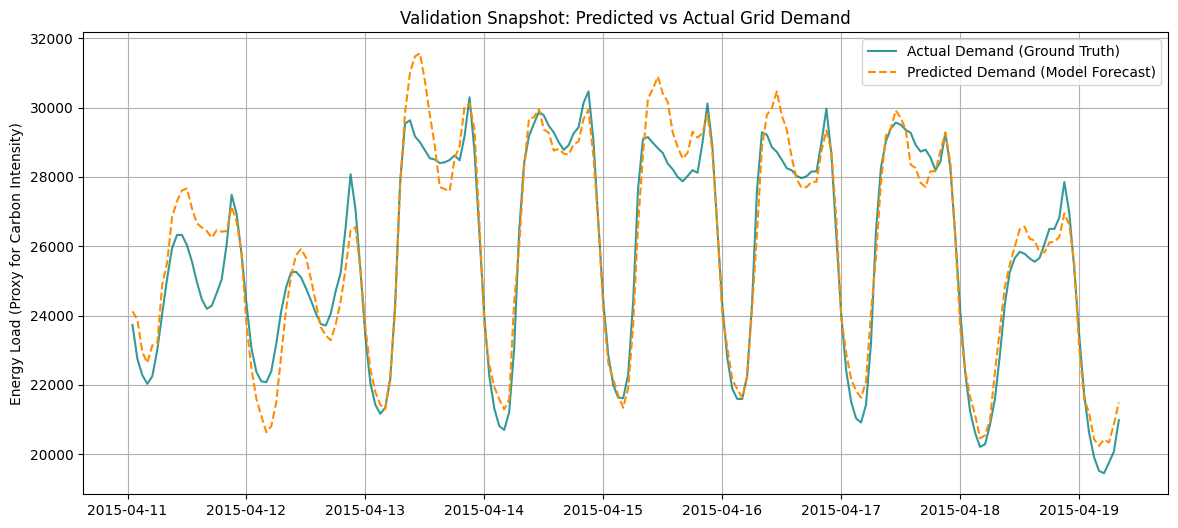

In [39]:
# Create a dataframe for visualization
results = pd.DataFrame({'Actual': y_test, 'Predicted': predictions}, index=y_test.index)

# Plot a snapshot (e.g., 200 hours from the test set) to see the tracking quality
plt.figure(figsize=(14, 6))
plt.plot(results['Actual'].iloc[:200], label='Actual Demand (Ground Truth)', color='teal', alpha=0.8)
plt.plot(results['Predicted'].iloc[:200], label='Predicted Demand (Model Forecast)', color='darkorange', linestyle='--')
plt.title('Validation Snapshot: Predicted vs Actual Grid Demand')
plt.ylabel('Energy Load (Proxy for Carbon Intensity)')
plt.legend()
plt.grid(True)
plt.show()

In [43]:
import joblib

# Create the models directory if you haven't already
#import os
#os.makedirs('../models', exist_ok=True)

# Save the trained regressor
joblib.dump(model, 'E:\green_sla_project\models\carbon_predictor.joblib')

# Save the test features and actuals to simulate our environment
X_test.to_csv('E:\green_sla_project\data\X_test_simulation.csv')
y_test.to_csv('E:\green_sla_project\data\y_test_simulation.csv')
print("Model and simulation data saved successfully!")

<>:8: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\g'
<>:12: SyntaxWarning: invalid escape sequence '\g'
<>:15: SyntaxWarning: invalid escape sequence '\g'
<>:8: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\g'
<>:12: SyntaxWarning: invalid escape sequence '\g'
<>:15: SyntaxWarning: invalid escape sequence '\g'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22716\2016889204.py:8: SyntaxWarning: invalid escape sequence '\g'
  joblib.dump(model, 'E:\green_sla_project\models\carbon_predictor.joblib')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22716\2016889204.py:11: SyntaxWarning: invalid escape sequence '\g'
  X_test.to_csv('E:\green_sla_project\data\X_test_simulation.csv')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22716\2016889204.py:12: SyntaxWarning: invalid escape sequence '\g'
  y_test.to_csv('E:\green_sla_project\data\y_test_simulation.csv')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22716\201

Model and simulation data saved successfully!


'E:\\green_sla_project\\data'